# 00 Overview: Boltz-2 head fine-tuning reproduction (Furui and Ohue)

Self-filling: re-run after more targets finish and every table below updates, no edits needed. Targets with missing data are listed as pending.

In [1]:

import sys; sys.path.insert(0, "/global/scratch/users/sergiomar10/boltzaff/pipeline_local")
from bft_replication import *
from bft_common import DATA, RUNS
import matplotlib.pyplot as plt
from IPython.display import display
style()


## 1. Pipeline status per target
Stage is the furthest stage reached: library (Boltz inputs prepared) -> ft_inputs (fine-tuning inputs and eval set) -> scoring (k of 16 arms scored; 16 = No-FT plus 3 budgets x 5 seeds) -> scored -> table2 (eval_headft_seeds output exists).

In [2]:
st = status().copy()
def stage(r):
    k = int(str(r.arms_scored).split("/")[0])
    if r.table2: return "table2 done"
    if k == 16: return "scored (table2 not written yet)"
    if k > 0: return f"scoring ({k}/16 arms)"
    if r.ft_inputs: return "ft_inputs ready, scoring not started"
    if r.library == r.library and r.library > 0: return "library inputs only"
    return "not started"
st["stage"] = st.apply(stage, axis=1); display(st)
DONE = done_targets("scores")
print(f"fully scored targets: {len(DONE)}/8 -> {[SHORT[t] for t in DONE]}")
for t in TARGETS:
    if t not in DONE: print(f"pending: {SHORT[t]} - {st.loc[SHORT[t], 'stage']}")

,library,ft_inputs,arms_scored,table2,stage
target,,,,,
588689,49985,True,16/16,True,table2 done
504329,49982,True,16/16,True,table2 done
743445,49995,True,16/16,True,table2 done
485317,49980,True,16/16,True,table2 done
2097,49915,False,0/16,False,library inputs only
493091,49985,True,0/16,False,"ft_inputs ready, scoring not started"
2650,49882,False,0/16,False,library inputs only
588549,49987,False,0/16,False,library inputs only


fully scored targets: 4/8 -> ['588689', '504329', '743445', '485317']
pending: 2097 - library inputs only
pending: 493091 - ft_inputs ready, scoring not started
pending: 2650 - library inputs only
pending: 588549 - library inputs only


## 2. Headline: ours vs the paper (scored targets)
No-FT AP, and head-FT AP at N=300 as mean and SD over the 5 seeds; ratio = head-FT mean / No-FT. Paper values are the single-seed numbers released in trainer_control.csv. Ratio SD is the seed SD of the head-FT AP divided by No-FT AP.

In [3]:
rows = []; MT = {}
for t in TARGETS:
    pb = PAPER_BASE.loc[t, "auprc"]; pf = PAPER_FT.loc[(t, 300), "auprc"]
    r = dict(target=SHORT[t], paper_NoFT_AP=pb, paper_FT300_AP=pf, paper_ratio=pf / pb, active_rate_pct=100 * RATE[t])
    try:
        d = metrics_table(t)
    except Exception as e:
        d = None; print(f"{SHORT[t]}: error {e!r}")
    if d is None:
        r.update(status="pending"); print(f"pending: {SHORT[t]} - needs all 16 arms scored")
    else:
        MT[t] = d; b = d[d.arm == "base"].ap.iloc[0]; f = d[(d.arm == "headft") & (d.n_train == 300)].ap
        r.update(ours_NoFT_AP=b, ours_FT300_AP_mean=f.mean(), ours_FT300_AP_sd=f.std(ddof=1), ours_ratio=f.mean() / b, ours_ratio_sd=f.std(ddof=1) / b, status="scored")
    rows.append(r)
H = pd.DataFrame(rows).set_index("target")
display(H.style.format(precision=3, na_rep="-"))
print(f"n targets scored = {len(MT)}")

pending: 2097 - needs all 16 arms scored
pending: 493091 - needs all 16 arms scored
pending: 2650 - needs all 16 arms scored
pending: 588549 - needs all 16 arms scored


,paper_NoFT_AP,paper_FT300_AP,paper_ratio,active_rate_pct,ours_NoFT_AP,ours_FT300_AP_mean,ours_FT300_AP_sd,ours_ratio,ours_ratio_sd,status
target,,,,,,,,,,
588689,0.096,0.237,2.464,0.797,0.097,0.207,0.015,2.124,0.153,scored
504329,0.047,0.222,4.764,0.882,0.051,0.174,0.021,3.424,0.418,scored
743445,0.022,0.048,2.172,0.270,0.022,0.043,0.002,1.919,0.091,scored
485317,0.036,0.060,1.671,1.918,0.039,0.054,0.002,1.395,0.061,scored
2097,0.081,0.286,3.526,0.836,-,-,-,-,-,pending
493091,0.059,0.095,1.600,1.487,-,-,-,-,-,pending
2650,0.071,0.117,1.641,1.093,-,-,-,-,-,pending
588549,0.006,0.007,1.101,0.302,-,-,-,-,-,pending


n targets scored = 4


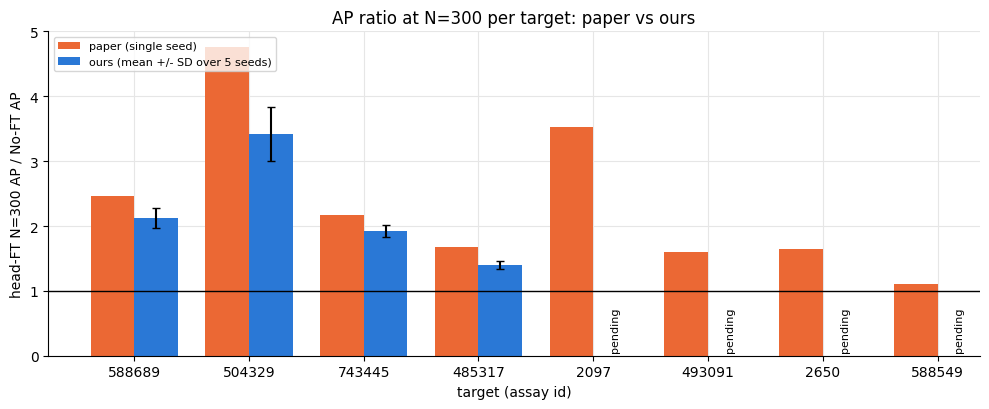

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.2)); x = np.arange(len(TARGETS)); w = 0.38
ax.bar(x - w/2, [H.loc[SHORT[t], "paper_ratio"] for t in TARGETS], w, color=THEIR, label="paper (single seed)")
ax.bar(x + w/2, [H.loc[SHORT[t]].get("ours_ratio", np.nan) for t in TARGETS], w, yerr=[H.loc[SHORT[t]].get("ours_ratio_sd", np.nan) if t in MT else 0 for t in TARGETS], capsize=3, color=OUR, label="ours (mean +/- SD over 5 seeds)")
for i, t in enumerate(TARGETS):
    if t not in MT: ax.text(i + w/2, 0.05, "pending", rotation=90, ha="center", va="bottom", fontsize=8)
ax.axhline(1, color="black", lw=1); ax.set_xticks(x); ax.set_xticklabels([SHORT[t] for t in TARGETS])
ax.set_xlabel("target (assay id)"); ax.set_ylabel("head-FT N=300 AP / No-FT AP"); ax.set_title("AP ratio at N=300 per target: paper vs ours"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. The data before any training: SD Z-score of actives and inactives
Each compound has the primary-screen **SD Z-score** (how many standard deviations the compound's readout lies from the plate/screen mean; it is the screen's raw hit strength, not a potency) and a binary label `target_active_v2`. The sign of a hit depends on the assay: in most targets actives have a high Z-score, but in one (see the table) actives are at strongly negative Z-scores, so the table works in the hit direction (the raw Z-score is what the density plots show). The label is the only ground truth used for training and evaluation; the Z-score is shown here only to see how clean the actives are and what the fine-tuning selection looks like. Every target's data is available now, so this section is complete for all 8 targets (n = number of compounds).

In [5]:
from scipy.stats import gaussian_kde
from sklearn.metrics import roc_auc_score
ZD = {}
for t in TARGETS:
    d = pd.read_csv(DATA / f"{t}.csv", usecols=["CID", "target_active_v2", "SD Z-score"]).rename(columns={"SD Z-score": "z"}); d["label"] = d.target_active_v2.astype(int); ZD[t] = d
rows = []; ORIENT = {}
for t in TARGETS:
    d = ZD[t]; ORIENT[t] = 1 if d[d.label == 1].z.median() > 0 else -1; d["zhit"] = d.z * ORIENT[t]       # hit direction: actives sit at high zhit
    a = d[d.label == 1].zhit; i = d[d.label == 0].zhit
    rows.append({"target": SHORT[t], "compounds": len(d), "actives": len(a), "inactives": len(i), "active rate %": round(100 * len(a) / len(d), 2),
                 "hits are at": "high Z" if ORIENT[t] > 0 else "LOW (negative) Z", "median raw Z actives": round(d[d.label == 1].z.median(), 2), "median raw Z inactives": round(d[d.label == 0].z.median(), 2),
                 "AUROC of hit-direction Z": round(roc_auc_score(d.label, d.zhit), 3), "% actives with hit-direction Z < 3": round(100 * (a < 3).mean(), 1), "% inactives with hit-direction Z > 3": round(100 * (i > 3).mean(), 2)})
display(pd.DataFrame(rows).set_index("target"))

,compounds,actives,inactives,active rate %,hits are at,median raw Z actives,median raw Z inactives,AUROC of hit-direction Z,% actives with hit-direction Z < 3,% inactives with hit-direction Z > 3
target,,,,,,,,,,
588689,49985,486,49499,0.97,high Z,4.53,-0.05,0.997,2.3,0.17
504329,49982,466,49516,0.93,high Z,4.45,-0.02,0.997,1.3,0.28
743445,49995,144,49851,0.29,high Z,9.56,-0.18,1.000,0.0,0.89
485317,49980,976,49004,1.95,high Z,3.68,-0.20,1.000,2.2,0.00
2097,49915,522,49393,1.05,LOW (negative) Z,-6.65,0.11,0.871,34.9,1.21
493091,49985,782,49203,1.56,high Z,7.02,-0.13,1.000,0.0,0.68
2650,49882,612,49270,1.23,high Z,5.94,-0.08,0.964,21.1,0.57
588549,49987,159,49828,0.32,high Z,4.88,0.06,1.000,11.3,0.01


### SD Z-score density, actives against inactives (n in each legend)
Smoothed density (each class normalised to area 1, so the 100-to-1 class imbalance does not hide the actives) of the Z-score, with the number of compounds in each class.

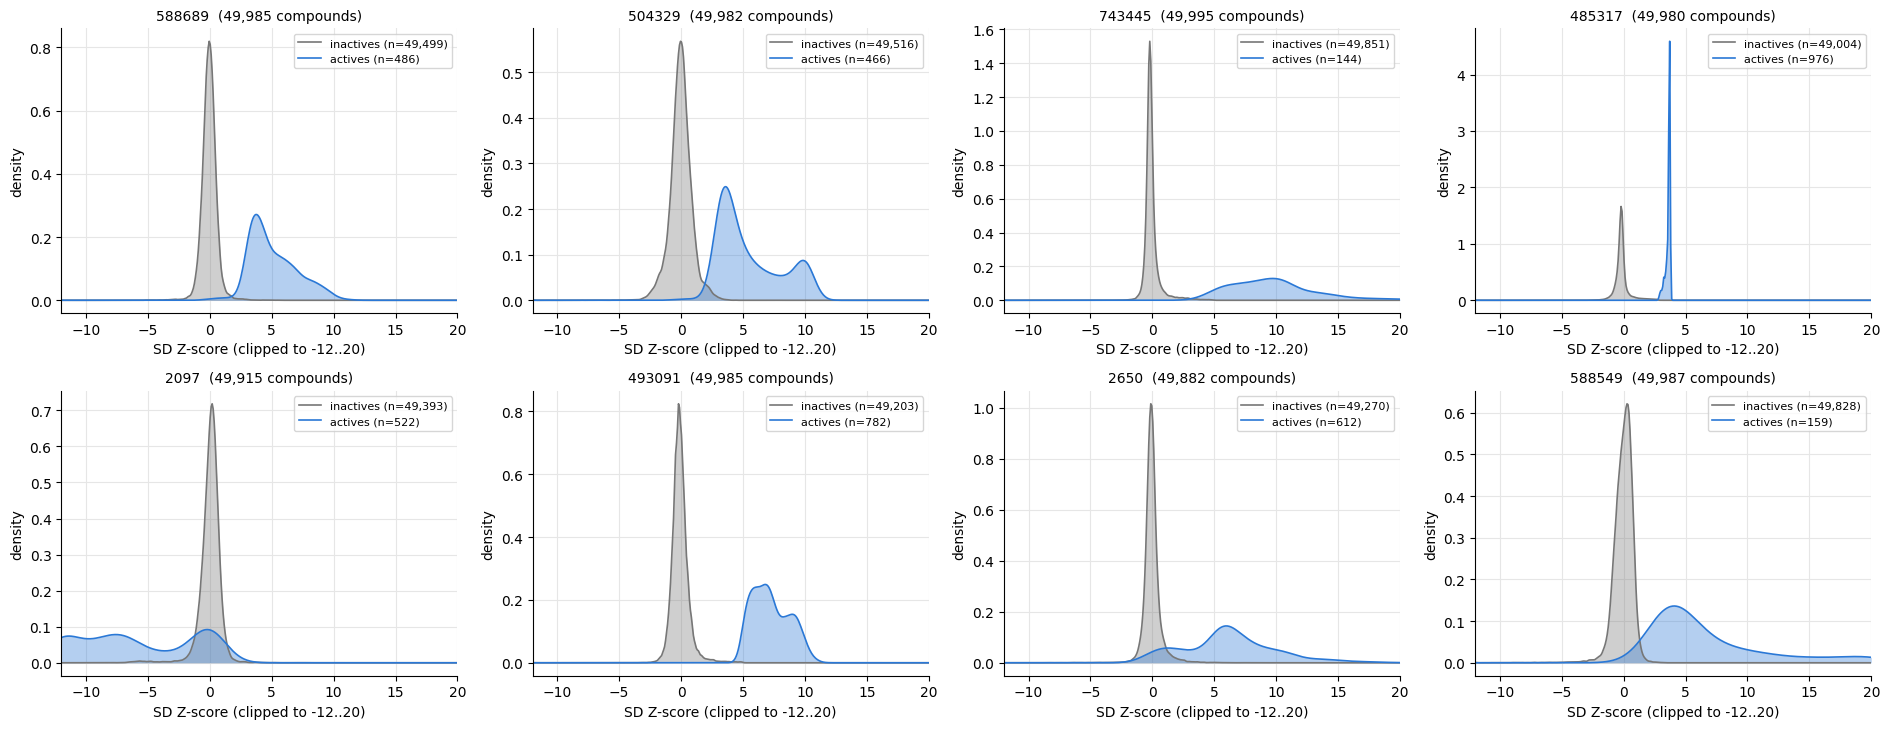

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(19, 7.4)); xs = np.linspace(-12, 20, 400)
for ax, t in zip(axes.ravel(), TARGETS):
    d = ZD[t]
    for lab, col, nm in ((0, "#777777", "inactives"), (1, OUR, "actives")):
        z = d[d.label == lab].z.clip(-12, 20).values
        ax.fill_between(xs, gaussian_kde(z)(xs), color=col, alpha=0.35, lw=0); ax.plot(xs, gaussian_kde(z)(xs), color=col, lw=1.2, label=f"{nm} (n={len(z):,})")
    ax.set_xlim(-12, 20); ax.set_xlabel("SD Z-score (clipped to -12..20)"); ax.set_ylabel("density"); ax.set_title(f"{SHORT[t]}  ({len(d):,} compounds)", fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### The same, as counts on a log axis
Histogram of compound counts per Z-score bin (log y), so the size of the inactive population and the tail of high-Z inactives are visible.

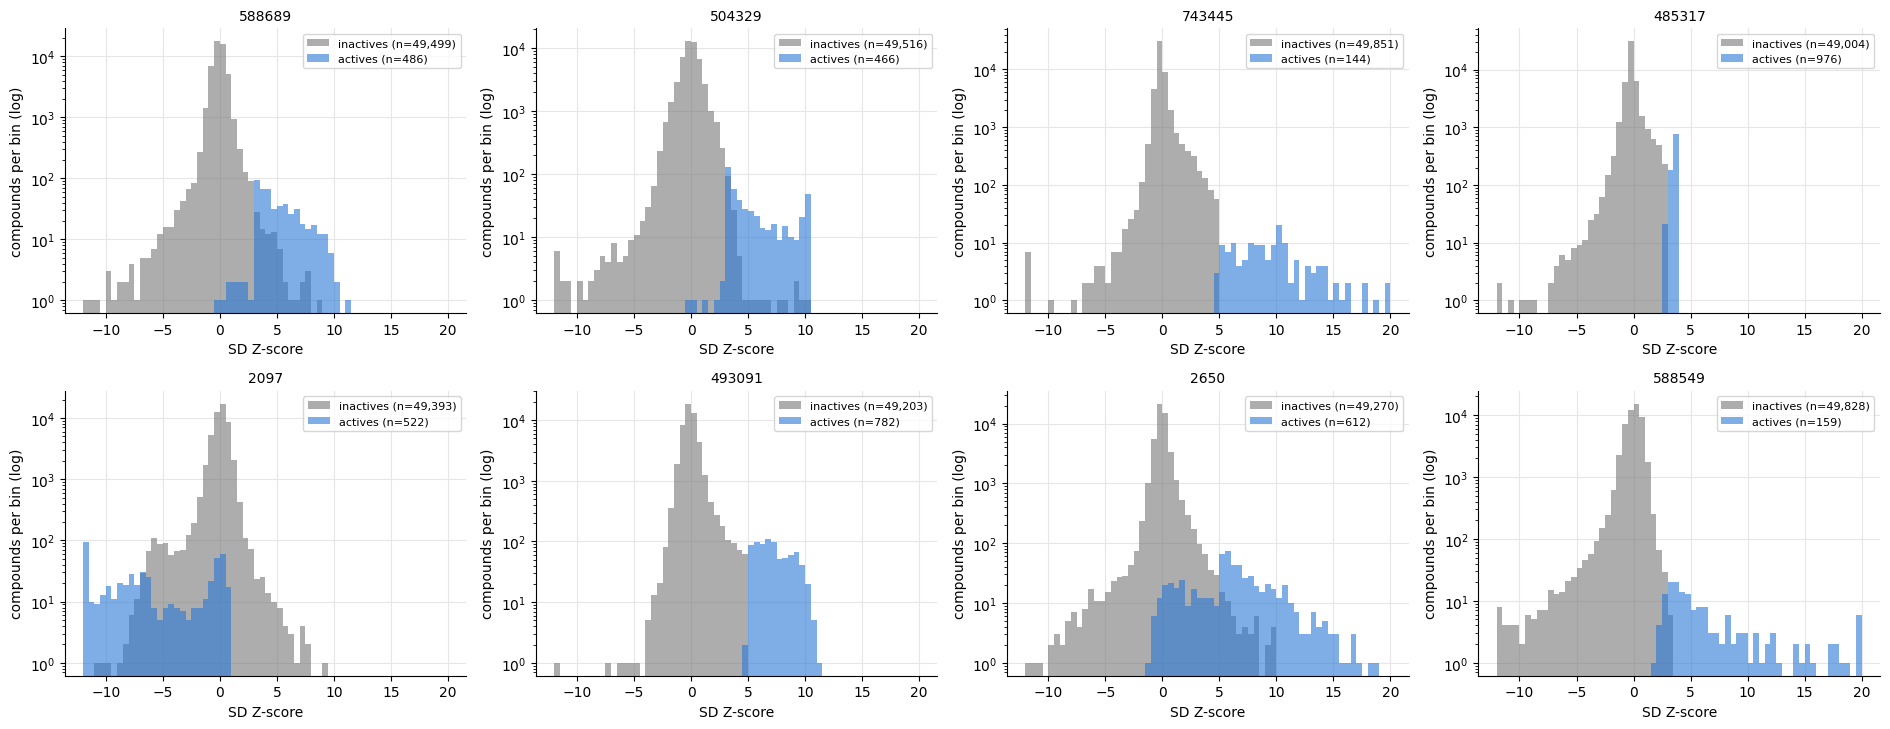

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(19, 7.4)); bins = np.linspace(-12, 20, 65)
for ax, t in zip(axes.ravel(), TARGETS):
    d = ZD[t]
    for lab, col, nm in ((0, "#777777", "inactives"), (1, OUR, "actives")):
        z = d[d.label == lab].z.clip(-12, 20).values; ax.hist(z, bins=bins, color=col, alpha=0.6, label=f"{nm} (n={len(z):,})")
    ax.set_yscale("log"); ax.set_xlabel("SD Z-score"); ax.set_ylabel("compounds per bin (log)"); ax.set_title(SHORT[t], fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### What goes into the fine-tuning: the training sets against the library
The training sets are the top-N compounds by the dataset's Boltz-2 score (N = 40, 100, 300), so they are not a random sample: they are the compounds the No-FT model already ranks highest. Per target: how many of them are actives, and where their Z-scores fall. Plots show the library densities (as above) with the **N = 300 training compounds as points** (blue = active, grey = inactive; vertical jitter only), with n for each.

training actives  training inactives  % active  \
target N                                                     
588689 40                 16                  24      40.0   
       100                32                  68      32.0   
       300                90                 210      30.0   
504329 40                  4                  36      10.0   
       100                11                  89      11.0   
       300                28                 272       9.3   
743445 40                  0                  40       0.0   
       100                 5                  95       5.0   
       300                10                 290       3.3   
485317 40                  1                  39       2.5   
       100                 9                  91       9.0   
       300                23                 277       7.7   
2097   40                 24                  16      60.0   
       100                52                  48      52.0   
       300               107                 193      35.7   
493091 40                  8                  32      20.0   
       100                16                  84      16.0   
       300                43                 257      14.3   
2650   40                 13                  27      32.5   
       100                29                  71      29.0   
       300                70                 230      23.3   
588549 40                  4                  36      10.0   
       100                 4                  96       4.0   
       300                 9                 291       3.0   

            library active rate %  median Z (train actives)  \
target N                                                      
588689 40                    0.80                      5.65   
       100                   0.80                      5.54   
       300                   0.80                      5.36   
504329 40                    0.88                      6.04   
       100                   0.88                      5.80   
       300                   0.88                      5.12   
743445 40                    0.27                       NaN   
       100                   0.27                     10.62   
       300                   0.27                     10.75   
485317 40                    1.92                      3.71   
       100                   1.92                      3.71   
       300                   1.92                      3.68   
2097   40                    0.84                     -7.91   
       100                   0.84                     -8.14   
       300                   0.84                     -7.89   
493091 40                    1.49                      7.02   
       100                   1.49                      6.95   
       300                   1.49                      6.82   
2650   40                    1.09                      5.94   
       100                   1.09                      6.31   
       300                   1.09                      5.92   
588549 40                    0.30                      5.29   
       100                   0.30                      5.29   
       300                   0.30                      3.39   

            median Z (train inactives)  
target N                                
588689 40                        -0.11  
       100                        0.18  
       300                        0.18  
504329 40                         0.14  
       100                        0.05  
       300                        0.13  
743445 40                         0.07  
       100                        0.07  
       300                       -0.03  
485317 40                        -0.20  
       100                       -0.13  
       300                       -0.12  
2097   40                        -0.45  
       100                       -0.10  
       300                       -0.01  
493091 40                        -0.30  
       100            

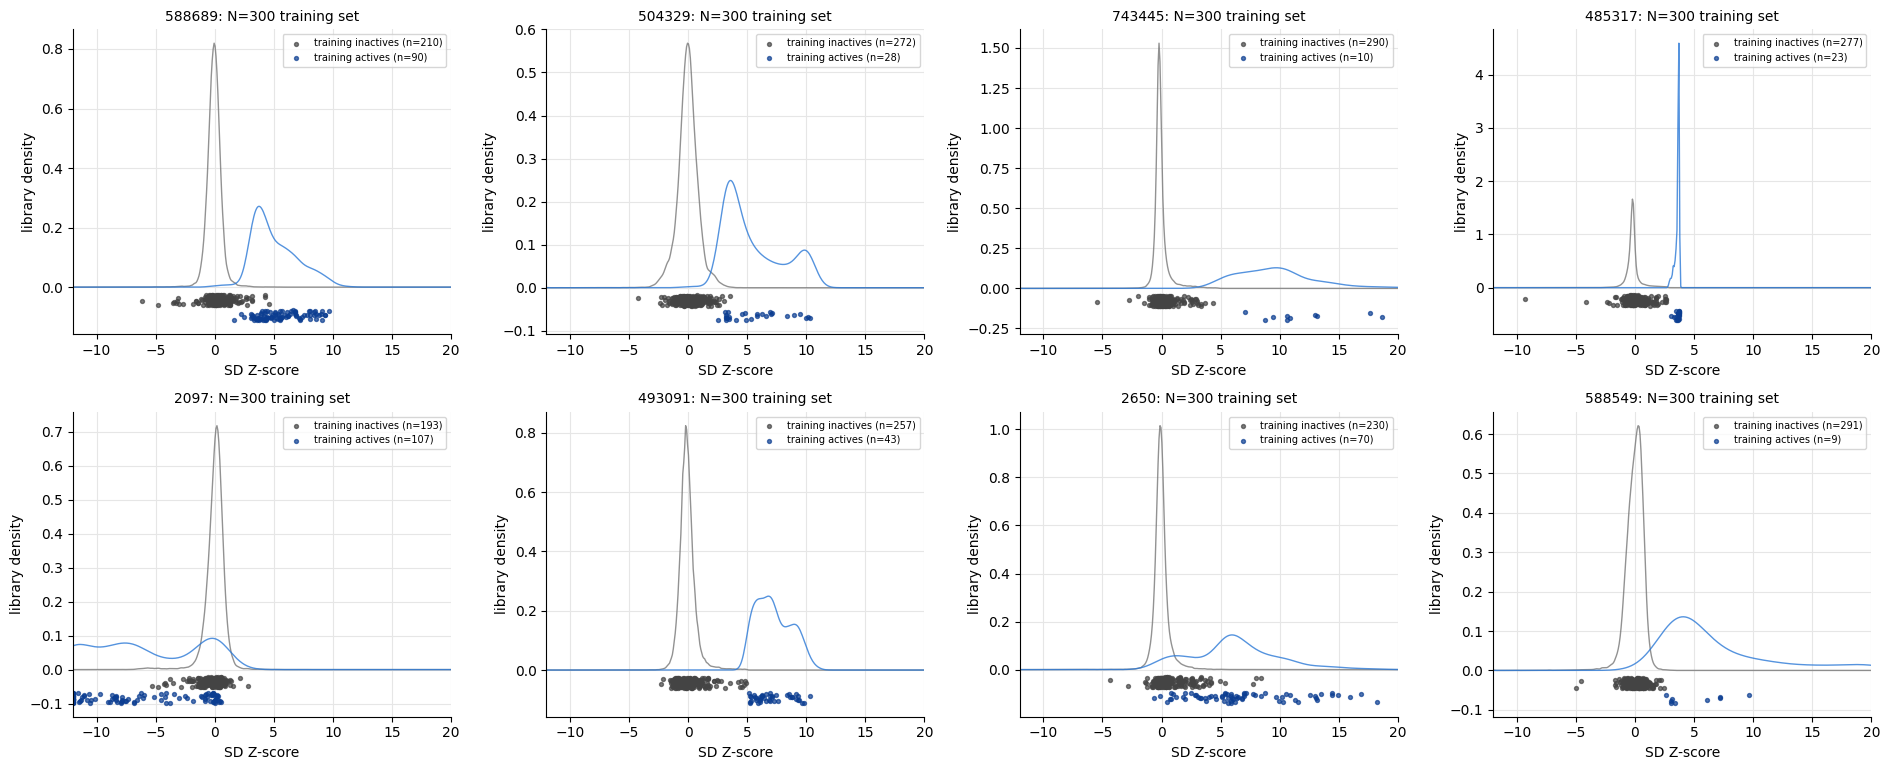

In [8]:
rows = []; TRN = {}
for t in TARGETS:
    for N in (40, 100, 300):
        p = RUNS / t / f"selection/train_top{N}.csv"
        if not p.exists(): continue
        tr = pd.read_csv(p, usecols=["CID", "Active_v2"]); m = tr.merge(ZD[t][["CID", "z", "label"]], on="CID", how="left"); TRN[(t, N)] = m
        a = m[m.Active_v2 == 1].z; i = m[m.Active_v2 == 0].z
        rows.append({"target": SHORT[t], "N": N, "training actives": len(a), "training inactives": len(i), "% active": round(100 * len(a) / len(m), 1), "library active rate %": round(100 * RATE[t], 2),
                     "median Z (train actives)": round(a.median(), 2) if len(a) else np.nan, "median Z (train inactives)": round(i.median(), 2) if len(i) else np.nan})
display(pd.DataFrame(rows).set_index(["target", "N"]))
rng = np.random.default_rng(0); fig, axes = plt.subplots(2, 4, figsize=(19, 7.8))
for ax, t in zip(axes.ravel(), TARGETS):
    d = ZD[t]
    for lab, col in ((0, "#777777"), (1, OUR)):
        ax.plot(xs, gaussian_kde(d[d.label == lab].z.clip(-12, 20).values)(xs), color=col, lw=1.0, alpha=0.8)
    if (t, 300) in TRN:
        m = TRN[(t, 300)]; top = ax.get_ylim()[1]
        for lab, col, nm in ((0, "#444444", "training inactives"), (1, "#0b3d91", "training actives")):
            z = m[m.Active_v2 == lab].z.clip(-12, 20).values; ax.scatter(z, -0.03 * top - 0.04 * top * rng.random(len(z)) - (0.06 * top if lab else 0), s=8, color=col, alpha=0.7, label=f"{nm} (n={len(z)})")
        ax.legend(fontsize=7, loc="upper right")
    ax.set_xlim(-12, 20); ax.set_xlabel("SD Z-score"); ax.set_ylabel("library density"); ax.set_title(f"{SHORT[t]}: N=300 training set", fontsize=10)
plt.tight_layout(); plt.show()

## 4. Notebook index
- **01_replication**: Table 2 style cross-target geometric-mean ratios (AP, EF@1%, BEDROC), per-target AP on a log axis with active-rate lines, seed spread, and whether the paper's headline is reproduced.
- **02_uncertainty**: whether the two-head disagreement of the affinity model flags unreliable predictions, before and after fine-tuning.
- **03_ft_vs_noft_reranking**: which compounds fine-tuning moves up or down the ranking relative to No-FT, and whether those moves are correct.
- **04_structural_cliffs**: activity-cliff pairs (similar structures, very different activity) and how well each model orders them.
- **05_pose_density_and_decoy**: where predicted poses sit in the pocket, and control experiments with decoy proteins.
- **06_training_strategies**: alternative training-set selections (for example balanced versus top-N actives) compared with the paper's recipe.

Some of these notebooks may not exist yet while they are being built.

In [9]:
nbs = ["01_replication", "02_uncertainty", "03_ft_vs_noft_reranking", "04_structural_cliffs", "05_pose_density_and_decoy", "06_training_strategies"]
for n in nbs: print(f"{n}.ipynb:", "present" if (ROOT / "notebooks" / f"{n}.ipynb").exists() else "not built yet")

01_replication.ipynb: present
02_uncertainty.ipynb: present
03_ft_vs_noft_reranking.ipynb: present
04_structural_cliffs.ipynb: present
05_pose_density_and_decoy.ipynb: present
06_training_strategies.ipynb: present
